# Imports and loading Data Downloaded

In [5]:
%pip install pandas
import pandas as pd
import numpy as np

orders = pd.read_csv("data/olist_orders_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
translations = pd.read_csv("data/product_category_name_translation.csv")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 2.8 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.9 MB 4.0 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 4.7 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/9.9 MB 5.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 5.2 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.9 MB 4.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 4.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 4.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.9 MB 4.4 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.2 MB/s  0:00:02

   -------------------------

In [10]:
reviews.head(2)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


In [11]:
orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


# Quick inspection

In [6]:
datasets = {
    "orders": orders,
    "reviews": reviews,
    "customers": customers,
    "order_items": order_items,
    "products": products,
    "translations": translations
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head(2))


ORDERS
--------------------------------------------------
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  

REVIEWS
------

# Check keys and possible duplicates

In [7]:
print("Orders order_id unique:", orders["order_id"].is_unique)
print("Customers customer_id unique:", customers["customer_id"].is_unique)
print("Products product_id unique:", products["product_id"].is_unique)

print("Reviews duplicate order_id count:", reviews["order_id"].duplicated().sum())
print("Order items duplicate order_id count:", order_items["order_id"].duplicated().sum())

Orders order_id unique: True
Customers customer_id unique: True
Products product_id unique: True
Reviews duplicate order_id count: 551
Order items duplicate order_id count: 13984


# Taking average of multiple reviews

In [8]:
reviews_clean = reviews.groupby("order_id", as_index=False).agg({
    "review_score": "mean"
})

In [ ]:
reviews_clean["order_id"].is_unique 

True

# Merge orders + customers

In [12]:
df = orders.merge(customers, on="customer_id", how="left")

# Merge reviews

In [13]:
df = df.merge(reviews_clean, on="order_id", how="left")

In [14]:
print("Final shape:", df.shape)
print("Order ID still unique:", df["order_id"].is_unique)

Final shape: (99441, 13)
Order ID still unique: True


In [18]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0


# Convert date columns

In [16]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [17]:
df.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0


# Create Delivery Delay Metric

In [19]:
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

# Handle invalid / missing deliveries
## Some orders:

### were canceled
### never delivered

In [20]:
df["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

# Filter valid deliveries

In [21]:
df_delivered = df[df["order_status"] == "delivered"].copy()
df_delivered.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0,-6.0


# Create Delivery Status Categories

In [22]:
def classify_delay(days):
    if pd.isna(days):
        return "Unknown"
    elif days <= 0:
        return "On Time"
    elif days <= 5:
        return "Late"
    else:
        return "Super Late"

df_delivered["delivery_status"] = df_delivered["delivery_delay_days"].apply(classify_delay)

In [23]:
df_delivered["delivery_status"].value_counts()

delivery_status
On Time       89936
Super Late     3764
Late           2770
Unknown           8
Name: count, dtype: int64

In [24]:
df_delivered["delivery_delay_days"].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

### Unknown = 8 fix

In [25]:
df_delivered = df_delivered.dropna(subset=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

# Calculate % Late per State

In [26]:
state_analysis = df_delivered.groupby("customer_state").agg(
    total_orders=("order_id", "count"),
    late_orders=("delivery_status", lambda x: ((x == "Late") | (x == "Super Late")).sum())
).reset_index()

state_analysis["late_percentage"] = (
    state_analysis["late_orders"] / state_analysis["total_orders"]
) * 100

state_analysis = state_analysis.sort_values(by="late_percentage", ascending=False)

In [29]:
state_analysis.head(20)

,customer_state,total_orders,late_orders,late_percentage
1,AL,397,85,21.410579
9,MA,717,125,17.433752
24,SE,335,51,15.223881
16,PI,476,66,13.865546
5,CE,1279,176,13.760751
21,RR,41,5,12.195122
4,BA,3256,396,12.162162
18,RJ,12350,1495,12.105263
13,PA,946,106,11.205074
7,ES,1995,214,10.726817


# Visualization

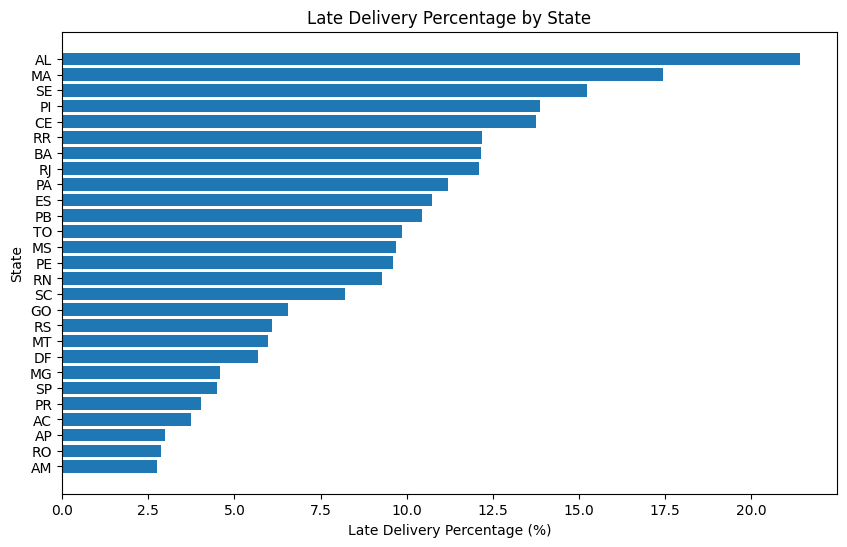

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(state_analysis["customer_state"], state_analysis["late_percentage"])
plt.xlabel("Late Delivery Percentage (%)")
plt.ylabel("State")
plt.title("Late Delivery Percentage by State")
plt.gca().invert_yaxis()
plt.show()

# Compare Review Scores
## A. Average score by delivery status

In [30]:
review_analysis = df_delivered.groupby("delivery_status").agg(
    avg_review_score=("review_score", "mean"),
    count=("order_id", "count")
).reset_index()

review_analysis

,delivery_status,avg_review_score,count
0,Late,2.988795,2770
1,On Time,4.290589,89936
2,Super Late,1.738453,3764


## B. Delay vs Review Score

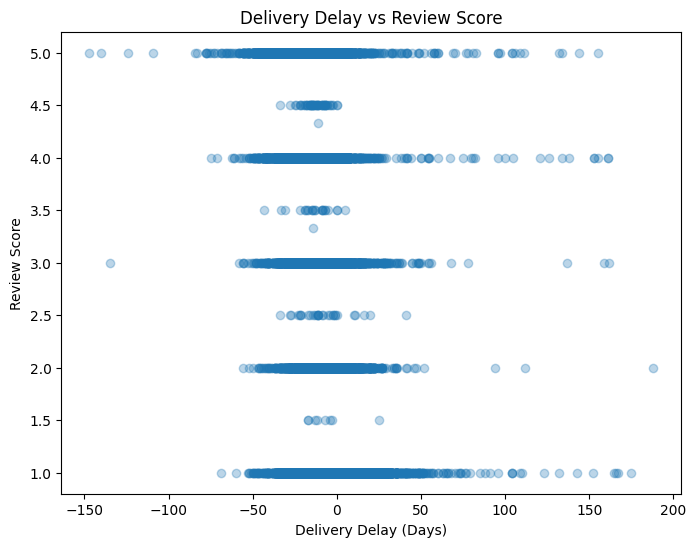

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_delivered["delivery_delay_days"], df_delivered["review_score"], alpha=0.3)
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Review Score")
plt.title("Delivery Delay vs Review Score")
plt.show()

# Prepare product-category mapping

In [32]:
order_items_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

# Translate categories to English

In [33]:
order_items_products = order_items_products.merge(
    translations,
    on="product_category_name",
    how="left"
)

In [34]:
order_items_products.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop


## Take the most frequent category per order

In [35]:
order_category = (
    order_items_products
    .groupby(["order_id", "product_category_name_english"])
    .size()
    .reset_index(name="count")
)

# pick most frequent category per order
order_category = order_category.sort_values(
    ["order_id", "count"],
    ascending=[True, False]
).drop_duplicates("order_id")

# Merge with the main dataset

In [36]:
df_category = df_delivered.merge(
    order_category[["order_id", "product_category_name_english"]],
    on="order_id",
    how="left"
)

In [38]:
df_category.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,delivery_delay_days,delivery_status,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0,-8.0,On Time,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0,-6.0,On Time,perfumery


In [39]:
print(df_category.shape)
print(df_category["order_id"].is_unique)

(96470, 16)
True


# Analyze delay by category

In [40]:
category_analysis = df_category.groupby("product_category_name_english").agg(
    total_orders=("order_id", "count"),
    late_orders=("delivery_status", lambda x: ((x == "Late") | (x == "Super Late")).sum())
).reset_index()

category_analysis["late_percentage"] = (
    category_analysis["late_orders"] / category_analysis["total_orders"]
) * 100

category_analysis = category_analysis.sort_values(
    by="late_percentage",
    ascending=False
)

### Focus on meaningful categories

In [41]:
category_analysis = category_analysis[category_analysis["total_orders"] > 100]

In [43]:
category_analysis.head(10)

,product_category_name_english,total_orders,late_orders,late_percentage
4,audio,348,41,11.781609
47,home_confort,346,35,10.115607
33,fashion_underwear_beach,117,11,9.401709
10,books_technical,256,21,8.203125
57,office_furniture,1244,101,8.118971
6,baby,2794,226,8.088762
12,christmas_supplies,125,10,8.000000
40,furniture_living_room,403,31,7.692308
26,electronics,2509,192,7.652451
56,musical_instruments,606,46,7.590759


# Visualize

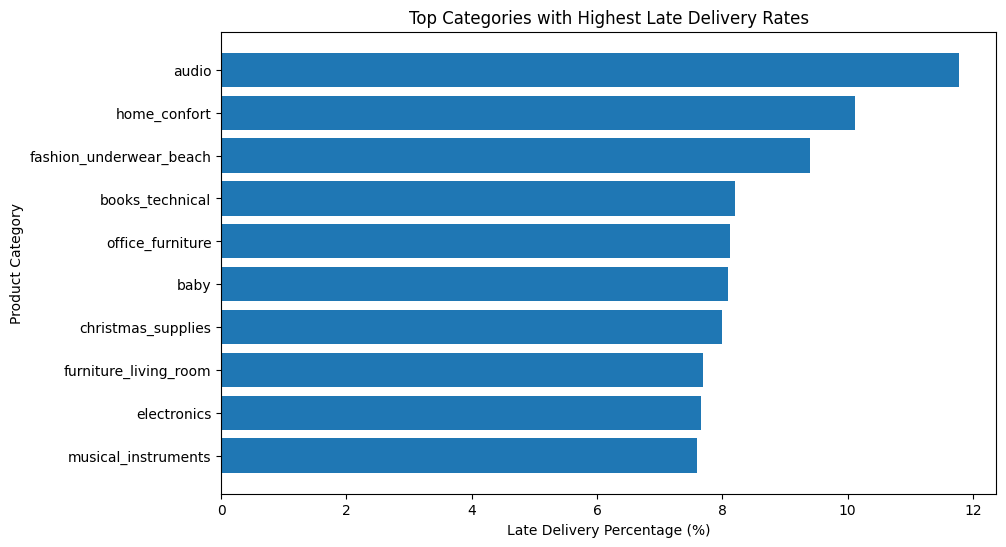

In [42]:
import matplotlib.pyplot as plt

top_categories = category_analysis.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["product_category_name_english"], top_categories["late_percentage"])
plt.xlabel("Late Delivery Percentage (%)")
plt.ylabel("Product Category")
plt.title("Top Categories with Highest Late Delivery Rates")
plt.gca().invert_yaxis()
plt.show()

In [44]:
df_category.to_csv("final_dataset.csv", index=False)